In [67]:
initial_words = open('names.txt','r').read().splitlines()
initial_words[:10]

['Aabhas',
 'Aabhash',
 'Aabhesh',
 'Aabhusan',
 'Aabhushan',
 'Aabish',
 'Aabishkar',
 'Aabiskar',
 'Aadarsh',
 'Aadarsha']

In [68]:
words = []
for word in initial_words:
    word = word.lower()
    words.append(word)
print(words[:10])

['aabhas', 'aabhash', 'aabhesh', 'aabhusan', 'aabhushan', 'aabish', 'aabishkar', 'aabiskar', 'aadarsh', 'aadarsha']


In [69]:
len(words)

8775

In [70]:
chars = sorted(list(set(''.join(words))))
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [71]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
print(stoi)
itos = {i:s for s, i in stoi.items()}
print(itos)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [72]:
import torch
N = torch.zeros((27, 27), dtype = torch.int32)

In [73]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        if ch1 == '.' and ch2 == '.':
            print(f"{ch1}, {ch2}")
    
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

(-0.5, 26.5, 26.5, -0.5)

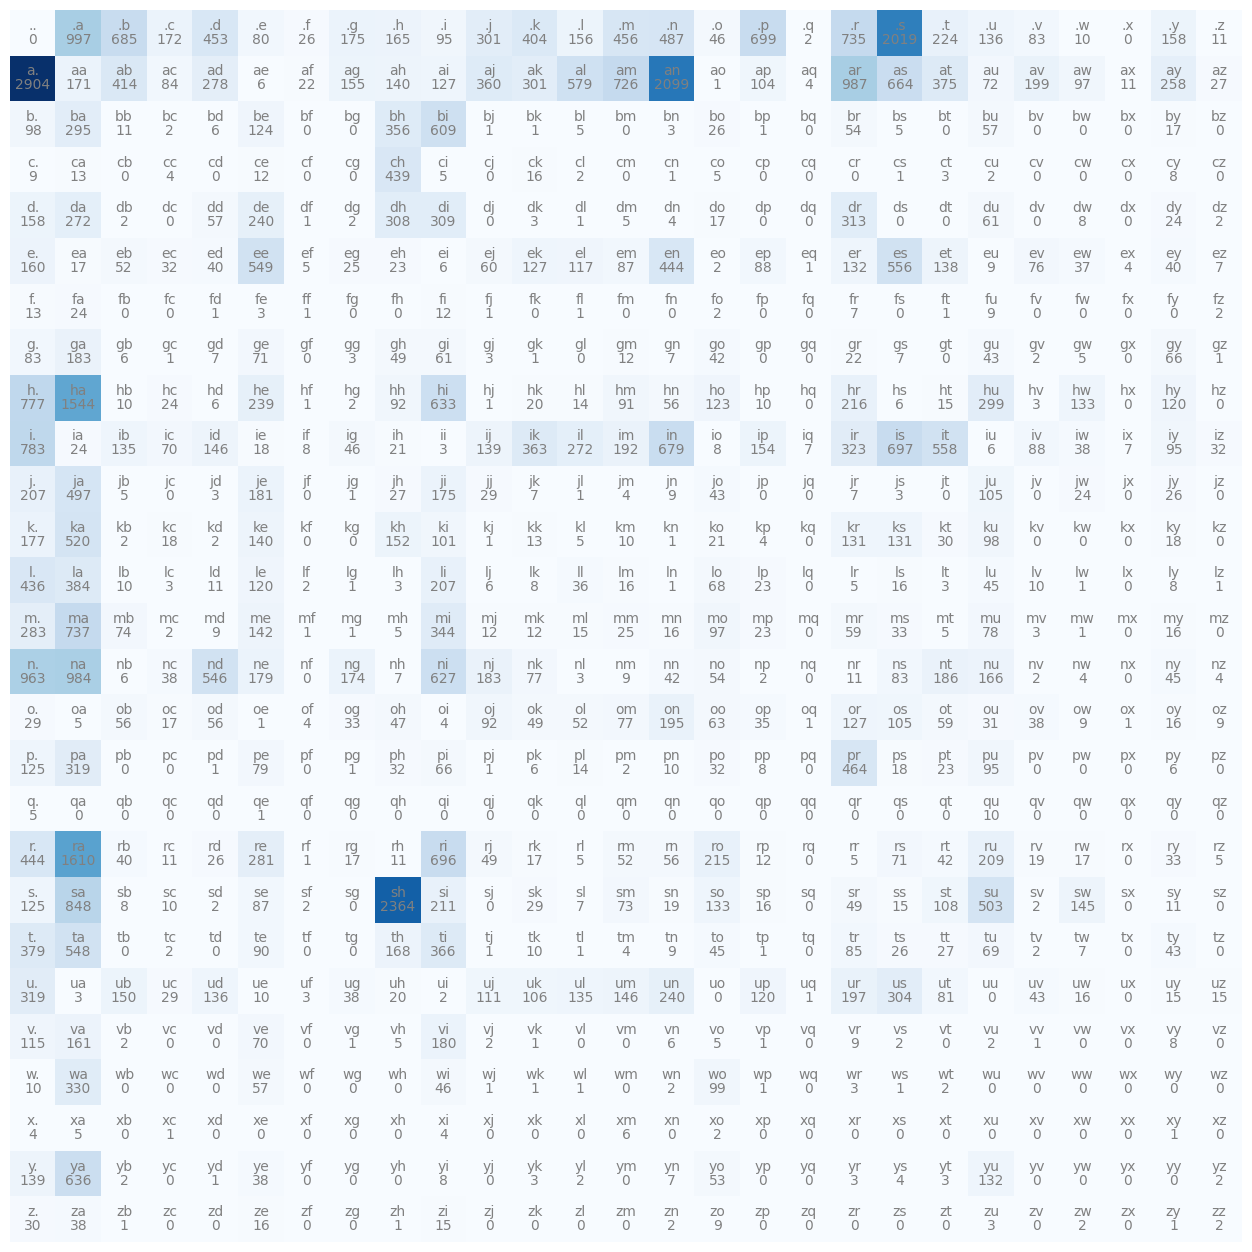

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i,j].item(), ha="center", va="top", color='gray')

plt.axis('off')

In [94]:
p = N[0].float()
p /= p.sum()
p


tensor([0.0000e+00, 1.1362e-01, 7.8063e-02, 1.9601e-02, 5.1624e-02, 9.1168e-03,
        2.9630e-03, 1.9943e-02, 1.8803e-02, 1.0826e-02, 3.4302e-02, 4.6040e-02,
        1.7778e-02, 5.1966e-02, 5.5499e-02, 5.2422e-03, 7.9658e-02, 2.2792e-04,
        8.3761e-02, 2.3009e-01, 2.5527e-02, 1.5499e-02, 9.4587e-03, 1.1396e-03,
        0.0000e+00, 1.8006e-02, 1.2536e-03])

In [95]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'j'

In [96]:
p.sum()

tensor(1.)

In [97]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [98]:
torch.multinomial(p, num_samples=100, replacement=True, generator=g)

tensor([1, 1, 2, 0, 0, 2, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 2, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 1, 0,
        0, 1, 1, 1])

In [81]:
p.shape

torch.Size([3])

In [99]:
P = (N+1).float()
P /= P.sum(1, keepdims=True)

In [109]:
g = torch.Generator().manual_seed(144748300)
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1 ,replacement=True, generator=g).item()
        out.append(itos[ix])
        #print(itos[ix])
        if ix == 0:
            break
    print(''.join(out))
    #print(out)

rant.
navami.
shyu.
il.
aja.
smbahashardh.
sit.
sujyanketijeesaatandiiy.
dewariraworeesa.
rabanilum.


In [110]:
log_likelihood = 0
n = 0 
for w in words:

    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]): 
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f"{ch1}{ch2}:{prob:.4f} {logprob:.4f}")

print(f"log_likelihood:{log_likelihood}")
nll = (-log_likelihood)
print(f"nll:{nll}")
print(nll/n)


log_likelihood:-147877.65625
nll:147877.65625
tensor(2.2661)


In [111]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)
    
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a a
a b
b h
h a
a s
s .


In [112]:
xs

tensor([ 0,  1,  1,  2,  8,  1, 19])

In [113]:
ys

tensor([ 1,  1,  2,  8,  1, 19,  0])

In [114]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0.]])

In [115]:
xenc.shape

torch.Size([7, 27])

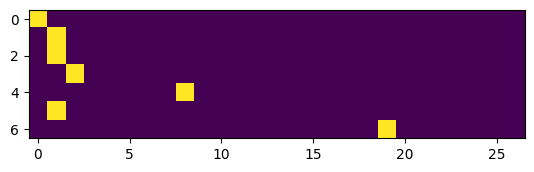

In [116]:
plt.imshow(xenc)

In [117]:
xenc.dtype

torch.float32

In [118]:
W = torch.randn((27, 27))
xenc @ W

tensor([[ 1.2614e+00, -1.3219e+00, -3.6829e+00,  6.3352e-01,  1.6870e+00,
          1.4545e-01,  4.4378e-01, -4.0883e-02, -6.2900e-01,  1.1409e+00,
         -1.8178e-01, -1.0151e+00,  3.1494e-01,  6.4206e-01,  9.3344e-01,
          1.6146e+00, -1.4474e+00, -3.9742e-01, -5.9956e-01,  1.3563e+00,
         -1.7599e+00,  6.1424e-01, -1.6499e+00,  2.0863e+00,  9.3795e-01,
          7.6334e-01,  1.1636e+00],
        [ 2.8003e-01,  1.7142e-01, -1.3791e+00, -1.6528e-02, -6.0336e-01,
          1.2268e+00,  4.4503e-03, -1.0114e-01, -5.6313e-01,  4.8845e-01,
         -2.0462e+00,  7.2463e-01, -1.7569e+00,  7.4814e-01,  6.1206e-01,
          9.2832e-01,  1.3192e+00,  5.4033e-01,  7.8669e-01,  3.0653e-01,
         -1.7288e+00,  7.3657e-01,  1.9000e-01, -1.3728e-01, -1.1622e+00,
          1.4460e+00, -1.2660e+00],
        [ 2.8003e-01,  1.7142e-01, -1.3791e+00, -1.6528e-02, -6.0336e-01,
          1.2268e+00,  4.4503e-03, -1.0114e-01, -5.6313e-01,  4.8845e-01,
         -2.0462e+00,  7.2463e-01, -1.75

In [119]:
logits = (xenc @ W) # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0654, 0.0049, 0.0005, 0.0349, 0.1001, 0.0214, 0.0289, 0.0178, 0.0099,
         0.0580, 0.0154, 0.0067, 0.0254, 0.0352, 0.0471, 0.0931, 0.0044, 0.0124,
         0.0102, 0.0719, 0.0032, 0.0342, 0.0036, 0.1492, 0.0473, 0.0397, 0.0593],
        [0.0340, 0.0305, 0.0065, 0.0253, 0.0141, 0.0878, 0.0258, 0.0233, 0.0147,
         0.0419, 0.0033, 0.0531, 0.0044, 0.0544, 0.0475, 0.0651, 0.0962, 0.0442,
         0.0565, 0.0350, 0.0046, 0.0537, 0.0311, 0.0224, 0.0080, 0.1093, 0.0073],
        [0.0340, 0.0305, 0.0065, 0.0253, 0.0141, 0.0878, 0.0258, 0.0233, 0.0147,
         0.0419, 0.0033, 0.0531, 0.0044, 0.0544, 0.0475, 0.0651, 0.0962, 0.0442,
         0.0565, 0.0350, 0.0046, 0.0537, 0.0311, 0.0224, 0.0080, 0.1093, 0.0073],
        [0.0031, 0.0399, 0.0304, 0.0050, 0.0188, 0.1006, 0.0085, 0.0716, 0.0081,
         0.0338, 0.0181, 0.0173, 0.0207, 0.0252, 0.0457, 0.1351, 0.0281, 0.0248,
         0.0083, 0.0024, 0.0075, 0.0164, 0.1284, 0.0168, 0.0846, 0.0812, 0.0194],
        [0.0106, 0.0190,

In [120]:
probs[0]

tensor([0.0654, 0.0049, 0.0005, 0.0349, 0.1001, 0.0214, 0.0289, 0.0178, 0.0099,
        0.0580, 0.0154, 0.0067, 0.0254, 0.0352, 0.0471, 0.0931, 0.0044, 0.0124,
        0.0102, 0.0719, 0.0032, 0.0342, 0.0036, 0.1492, 0.0473, 0.0397, 0.0593])

In [121]:
probs[1].sum()


tensor(1.)

In [122]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(144748300)
W = torch.randn((27, 27), generator=g ,requires_grad=True)

In [123]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# the last 2 lines here are together called a 'softmax'


In [127]:
probs.shape

torch.Size([7, 27])

In [128]:
nlls = torch.zeros(5)
for i in range(5):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())


--------
bigram example 1: .a (indexes 0,1)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0119, 0.0191, 0.0056, 0.0785, 0.0145, 0.0351, 0.0233, 0.0092, 0.0117,
        0.0446, 0.0253, 0.1134, 0.0111, 0.0297, 0.0175, 0.0503, 0.0173, 0.0386,
        0.1150, 0.0126, 0.0935, 0.1363, 0.0116, 0.0371, 0.0284, 0.0051, 0.0038],
       grad_fn=<SelectBackward0>)
label (actual next character): 1
probability assigned by the net to the the correct character: 0.019098201766610146
log likelihood: -3.9581611156463623
negative log likelihood: 3.9581611156463623
--------
bigram example 2: aa (indexes 1,1)
input to the neural net: 1
output probabilities from the neural net: tensor([0.0077, 0.1228, 0.0152, 0.2934, 0.0280, 0.0535, 0.0112, 0.0173, 0.0071,
        0.0228, 0.0058, 0.0146, 0.0518, 0.0160, 0.0100, 0.0114, 0.0076, 0.1257,
        0.0290, 0.0038, 0.0258, 0.0069, 0.0222, 0.0456, 0.0279, 0.0151, 0.0018],
       grad_fn=<SelectBackward0>)
label (actual next character

In [129]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

number of examples:  65256


In [131]:

# initialize the 'network'
g = torch.Generator().manual_seed(144748300)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [132]:

# gradient descent
for k in range(1000):
  
  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  
  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()
  
  # update
  W.data += -50 * W.grad
print(loss.item())


2.2922770977020264


In [147]:


for i in range(10):
  
    out = []
    ix = 0
    while True:
        
        # ----------
        # BEFORE:
        #p = P[ix]
        # ----------
        # NOW:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W # predict log-counts
        counts = logits.exp() # counts, equivalent to N
        p = counts / counts.sum(1, keepdims=True) # probabilities for next character
        # ----------
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(''.join(out))

bavit.
bikya.
ja.
rarisu.
ashen.
swar.
saunchee.
tur.
ashl.
pri.
